# Campione d'inverno e scudetto

L'ipotesi popolare è netta: chi è campione d'inverno vince lo scudetto.
**Sarà davvero così?** Lo mettiamo alla prova coi dati.

Due domande:

1. Qual è la probabilità che il campione d'inverno vinca lo scudetto? Il calcolo è fatto all'inverno, cioè a fine girone di andata.
2. E l'Inter, da campione d'inverno, che probabilità aveva?

I dati arrivano già puliti da `data/silver/` (la pipeline è negli script, vedi README). Qui c'è solo l'analisi.

### Librerie

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split, LeaveOneOut
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

## I dati

Una stagione per file in `data/silver/`, con le sole colonne che servono: data, squadre, gol. Li carico in un dizionario `campionati`, chiave = stagione.

In [2]:
# Carico le stagioni pulite da data/silver/: chiave = stagione, valore = DataFrame.
from pathlib import Path

SILVER = Path("../data/silver")
campionati = {
    f.stem.replace("I1_", ""): pd.read_csv(f)
    for f in sorted(SILVER.glob("I1_*.csv"))
}
print("Stagioni caricate:", len(campionati))

Stagioni caricate: 33


## Domanda 1 - la probabilità storica

Quante volte, dal 1993/94 a oggi, il campione d'inverno ha poi vinto lo scudetto?

Per ogni stagione ricostruisco la classifica fino alla fine del girone di andata (l'inverno), prendo il primo, e guardo se è lo stesso che vince a fine stagione.

In [3]:
def prepara_partite(df):
    """Colonne utili, date parsate, ordine cronologico, righe incomplete scartate."""
    m = df[["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG"]].copy()
    m["Date"] = pd.to_datetime(m["Date"], format="mixed", dayfirst=True)
    m["FTHG"] = pd.to_numeric(m["FTHG"], errors="coerce")
    m["FTAG"] = pd.to_numeric(m["FTAG"], errors="coerce")
    return m.dropna().sort_values("Date").reset_index(drop=True)


def classifica(partite):
    """Classifica vettorializzata (GP, GF, GA, GD, Pts), ordinata per Pts, GD, GF."""
    casa = partite[["HomeTeam", "FTHG", "FTAG"]].rename(
        columns={"HomeTeam": "team", "FTHG": "gf", "FTAG": "ga"})
    trasferta = partite[["AwayTeam", "FTAG", "FTHG"]].rename(
        columns={"AwayTeam": "team", "FTAG": "gf", "FTHG": "ga"})
    lungo = pd.concat([casa, trasferta], ignore_index=True)
    lungo["pts"] = (lungo["gf"] > lungo["ga"]) * 3 + (lungo["gf"] == lungo["ga"]) * 1
    tab = lungo.groupby("team").agg(
        GP=("pts", "size"), GF=("gf", "sum"), GA=("ga", "sum"), Pts=("pts", "sum"))
    tab["GD"] = tab["GF"] - tab["GA"]
    return tab.sort_values(["Pts", "GD", "GF"], ascending=False)


def istantanee_stagione(df):
    """Classifica del campione d'inverno (fine girone di andata) e finale."""
    m = prepara_partite(df)
    n_squadre = pd.concat([m["HomeTeam"], m["AwayTeam"]]).nunique()
    apparizioni = pd.concat([
        pd.DataFrame({"team": m["HomeTeam"].values, "partita": m.index}),
        pd.DataFrame({"team": m["AwayTeam"].values, "partita": m.index}),
    ]).sort_values("partita")
    apparizioni["giocate"] = apparizioni.groupby("team").cumcount() + 1
    fine_andata = apparizioni.loc[apparizioni["giocate"] == n_squadre - 1, "partita"].max()
    return classifica(m[m.index <= fine_andata]), classifica(m)


def costruisci_dataset(campionati):
    """Un record per stagione: campione d'inverno, distacco sul 2deg, GD, scudetto."""
    righe = []
    for stagione, df in campionati.items():
        inverno, finale = istantanee_stagione(df)
        righe.append({
            "Team": inverno.index[0],
            "Season": stagione,
            "GapOnSecond": int(inverno.iloc[0]["Pts"] - inverno.iloc[1]["Pts"]),
            "GD": int(inverno.iloc[0]["GD"]),
            "WonScudetto": int(inverno.index[0] == finale.index[0]),
        })
    return pd.DataFrame(righe)

In [4]:
righe = []
for stagione, df in campionati.items():
    inverno, finale = istantanee_stagione(df)
    righe.append((stagione, inverno.index[0], finale.index[0], inverno.index[0] == finale.index[0]))

res = pd.DataFrame(righe, columns=["season", "winter", "final", "same"]).sort_values("season").reset_index(drop=True)
print(res)
print("\nP(scudetto | campione d'inverno) =", res["same"].mean())

   season      winter     final   same
0    0001        Roma      Roma   True
1    0102        Roma  Juventus  False
2    0203       Milan  Juventus  False
3    0304        Roma     Milan  False
4    0405    Juventus  Juventus   True
5    0506    Juventus  Juventus   True
6    0607       Inter     Inter   True
7    0708       Inter     Inter   True
8    0809       Inter     Inter   True
9    0910       Inter     Inter   True
10   1011       Milan     Milan   True
11   1112    Juventus  Juventus   True
12   1213    Juventus  Juventus   True
13   1314    Juventus  Juventus   True
14   1415    Juventus  Juventus   True
15   1516      Napoli  Juventus  False
16   1617    Juventus  Juventus   True
17   1718      Napoli  Juventus  False
18   1819    Juventus  Juventus   True
19   1920    Juventus  Juventus   True
20   2021       Milan     Inter  False
21   2122       Inter     Milan  False
22   2223      Napoli    Napoli   True
23   2324       Inter     Inter   True
24   2425      Napoli    

## Esplorativa

Prima dei modelli, qualche numero descrittivo:
- quante stagioni e quante squadre;
- quanti campioni d'inverno e quanti campioni finali distinti;
- la conversione campione d'inverno -> scudetto, per squadra;
- chi ha vinto lo scudetto **senza** essere campione d'inverno;
- e quante squadre sono state campione d'inverno **senza** poi vincere.

In [ ]:
tutte_le_squadre = set()
for df in campionati.values():
    tutte_le_squadre |= set(df["HomeTeam"]) | set(df["AwayTeam"])

print("Stagioni osservate:", len(res))
print("Squadre distinte (tutte le stagioni):", len(tutte_le_squadre))
print("Campioni d'inverno distinti:", res["winter"].nunique())
print("Campioni finali distinti:", res["final"].nunique())

conv = res.groupby("winter").agg(
    volte_inverno=("same", "size"),
    poi_campione=("same", "sum"),
)
conv["quota"] = (conv["poi_campione"] / conv["volte_inverno"]).round(2)
conv = conv.sort_values(["volte_inverno", "poi_campione"], ascending=False)
print("\nConversione campione d'inverno -> scudetto, per squadra:")
print(conv)

rimonte = res.loc[~res["same"], ["season", "winter", "final"]]
print(f"\nScudetto senza essere campione d'inverno: {len(rimonte)} stagioni")
print(rimonte.to_string(index=False))
print("\nLo scudetto l'ha vinto (rimontando), per squadra:")
print(rimonte["final"].value_counts().to_string())
print(f"\nCampioni d'inverno che NON hanno poi vinto: {rimonte['winter'].nunique()} squadre (con le stagioni):")
manca = (rimonte.groupby("winter")
         .agg(volte=("season", "size"), stagioni=("season", lambda s: ", ".join(sorted(s))))
         .sort_values("volte", ascending=False))
print(manca.to_string())

## Tavola di contingenza

La domanda mette a confronto due probabilita': scudetto **se** campione d'inverno
contro scudetto **se non** campione d'inverno. La guardiamo su tutte le coppie
squadra-stagione, con il test esatto di Fisher (adatto ai conteggi piccoli).

In [6]:
from scipy.stats import fisher_exact, chi2_contingency
from statsmodels.stats.proportion import proportion_confint

# coppie squadra-stagione totali
n_ts = sum(len(set(df["HomeTeam"]) | set(df["AwayTeam"])) for df in campionati.values())

a = int(res["same"].sum())     # campione d'inverno e poi scudetto
b = len(res) - a               # campione d'inverno ma non scudetto
c = b                          # non camp. d'inverno ma scudetto (1 campione per stagione)
d = n_ts - a - b - c           # non camp. d'inverno e non scudetto

tabella = pd.DataFrame(
    [[a, b], [c, d]],
    index=["camp. d'inverno", "non camp. d'inverno"],
    columns=["scudetto", "no scudetto"],
)
print("Tavola di contingenza (coppie squadra-stagione) - frequenze:")
print(tabella)

perc = (tabella.div(tabella.sum(axis=1), axis=0) * 100).round(1)
print("\n% per riga  (= P(esito | riga)):")
print(perc)

lo, hi = proportion_confint(a, a + b, method="wilson")
print(f"\nP(scudetto | camp. d'inverno)     = {a / (a + b):.3f}  IC95% Wilson [{lo:.2f}, {hi:.2f}]")
print(f"P(scudetto | NON camp. d'inverno) = {c / (c + d):.4f}")

odds, p_f = fisher_exact([[a, b], [c, d]])
chi2, p_chi2, dof, attesi = chi2_contingency([[a, b], [c, d]])
print(f"\nFisher esatto: odds ratio = {odds:.1f}, p-value = {p_f:.2e}")
print(f"Chi-quadro:    {chi2:.1f} (dof={dof}), p-value = {p_chi2:.2e}")
print(f"Frequenza attesa minima = {attesi.min():.1f}  -> < 5: il test affidabile e' Fisher.")

Tavola di contingenza (coppie squadra-stagione) - frequenze:
                     scudetto  no scudetto
camp. d'inverno            24            9
non camp. d'inverno         9          596

% per riga  (= P(esito | riga)):
                     scudetto  no scudetto
camp. d'inverno          72.7         27.3
non camp. d'inverno       1.5         98.5

P(scudetto | camp. d'inverno)     = 0.727  IC95% Wilson [0.56, 0.85]
P(scudetto | NON camp. d'inverno) = 0.0149

Fisher esatto: odds ratio = 176.6, p-value = 6.08e-29
Chi-quadro:    309.4 (dof=1), p-value = 2.91e-69
Frequenza attesa minima = 1.7  -> < 5: il test affidabile e' Fisher.


**Perché Fisher e non chi-quadro.** Il χ² si appoggia a un'approssimazione asintotica
valida solo se le frequenze attese sono abbastanza grandi (regola pratica: tutte ≥ 5).
Qui l'attesa della cella «campione d'inverno e scudetto» è 1,7 < 5, quindi quel p-value
non è affidabile. Il test esatto di Fisher non approssima nulla: a margini fissati calcola
la probabilità esatta con la distribuzione ipergeometrica, ed è valido proprio coi conteggi
piccoli. Stessa conclusione (associazione fortissima), ma il numero da citare è quello di Fisher.

**Perché l'intervallo di Wilson.** Il 72,7% è una stima da sole 33 osservazioni: senza una
banda d'incertezza è un numero monco. L'intervallo classico (Wald, `p ± z·√(p(1-p)/n)`) qui
è inadatto — con n piccolo e proporzione lontana da 0,5 ha copertura scadente e può sforare
sotto 0 o sopra 1. L'intervallo di Wilson corregge entrambi i problemi: resta dentro [0, 1],
è asimmetrico (com'è giusto per una proporzione vicina agli estremi) e tiene la copertura
nominale anche con pochi dati. Da qui l'IC95% [0,56, 0,85]: la stima migliore è 73%, ma con
33 stagioni il vero valore può ragionevolmente stare fra il 56% e l'85%.

Un'avvertenza: le 605 coppie «non campione d'inverno» sono trattate come indipendenti, ma
sono legate dentro la stessa stagione (un solo scudetto per anno). Il messaggio resta valido,
però quel campione gonfiato è il motivo per cui entrambi i test escono estremamente significativi.

## Distribuzioni dei punti

Quanti punti fa il campione d'inverno all'andata, quanti il campione d'Italia a
fine stagione, e quanti ne aggiunge il campione dopo l'inverno. Con gli indici di
dispersione (dev. std, coefficiente di variazione, asimmetria, curtosi).

Indici di dispersione:
        winter  final  delta
mean     43.76  83.12  40.09
median   44.00  84.00  40.00
std       5.80   9.14   4.82
skew     -0.22  -0.16   0.64
kurt     -1.02  -0.70  -0.05
CV%      13.30  11.00  12.00


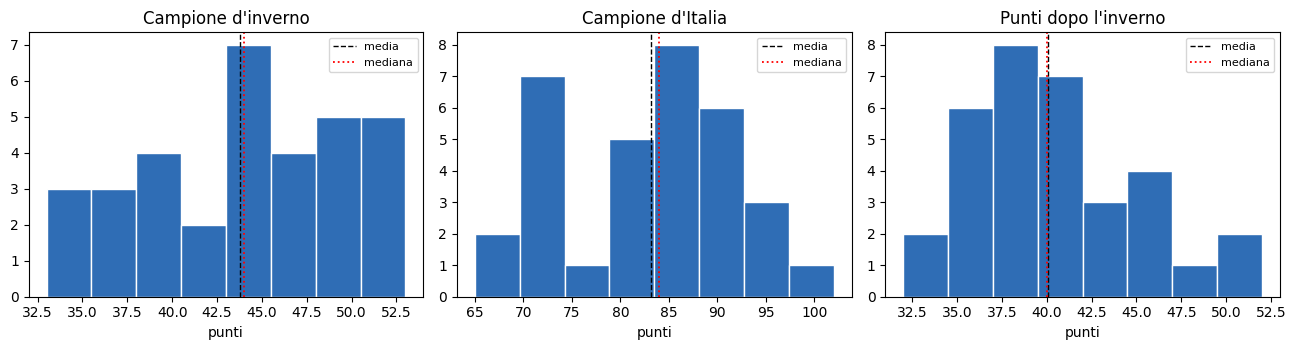

In [7]:
import matplotlib.pyplot as plt

punti = []
for stagione, df in campionati.items():
    inverno, finale = istantanee_stagione(df)
    campione = finale.index[0]
    punti.append({
        "winter": inverno.iloc[0]["Pts"],
        "final": finale.iloc[0]["Pts"],
        "delta": finale.iloc[0]["Pts"] - inverno.loc[campione, "Pts"],
    })
punti = pd.DataFrame(punti)

indici = punti.agg(["mean", "median", "std", "skew", "kurt"]).round(2)
indici.loc["CV%"] = (100 * punti.std() / punti.mean()).round(1)
print("Indici di dispersione:")
print(indici)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
etich = [("winter", "Campione d'inverno"), ("final", "Campione d'Italia"), ("delta", "Punti dopo l'inverno")]
for a, (col, tit) in zip(ax, etich):
    a.hist(punti[col], bins=8, color="#2F6DB5", edgecolor="white")
    a.axvline(punti[col].mean(), color="k", ls="--", lw=1, label="media")
    a.axvline(punti[col].median(), color="r", ls=":", lw=1.3, label="mediana")
    a.set_title(tit); a.set_xlabel("punti"); a.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Conversione per era

La risposta cambia molto col perimetro. Confrontiamo l'era a 18 squadre
(fino al 2003/04) con quella a 20 squadre (dal 2004/05): il primato d'inverno
e' un indicatore molto piu' forte nella Serie A moderna.

In [8]:
righe_era = []
for stagione, df in campionati.items():
    inverno, finale = istantanee_stagione(df)
    righe_era.append({"n_squadre": inverno.shape[0], "same": inverno.index[0] == finale.index[0]})
era = pd.DataFrame(righe_era)
era["era"] = era["n_squadre"].map({18: "18 squadre (<=2003/04)", 20: "20 squadre (2004/05+)"})

tab_era = era.groupby("era").agg(stagioni=("same", "size"), poi_campione=("same", "sum"))
tab_era["quota"] = (tab_era["poi_campione"] / tab_era["stagioni"]).round(2)
print(tab_era)
print(f"\nTotale: {era['same'].sum()}/{len(era)} = {era['same'].mean():.1%}")
print("Contesto (Lega Serie A, tutta la storia, 93 stagioni): 63/93 = 67,7%")

# Pochi dati per era: gli intervalli di Wilson sono larghi e si sovrappongono
print()
for et, g in era.groupby("era"):
    k, nn = int(g["same"].sum()), len(g)
    lo, hi = proportion_confint(k, nn, method="wilson")
    print(f"{et}: Wilson 95% {lo:.0%}-{hi:.0%}")

                        stagioni  poi_campione  quota
era                                                  
18 squadre (<=2003/04)        11             6   0.55
20 squadre (2004/05+)         22            18   0.82

Totale: 24/33 = 72.7%
Contesto (Lega Serie A, tutta la storia, 93 stagioni): 63/93 = 67,7%

18 squadre (<=2003/04): Wilson 95% 28%-79%
20 squadre (2004/05+): Wilson 95% 61%-93%


## Come si assesta la stima

La conversione storica non e' un numero fisso: cumulata stagione dopo stagione
parte ballerina (pochi dati), scende nell'era a 18 squadre e si assesta verso il
73% solo nell'era moderna. La banda di Wilson mostra quanta incertezza resta.
Le stagioni vanno ordinate per anno vero (il codice stringa metterebbe i 2000
prima dei 1990).

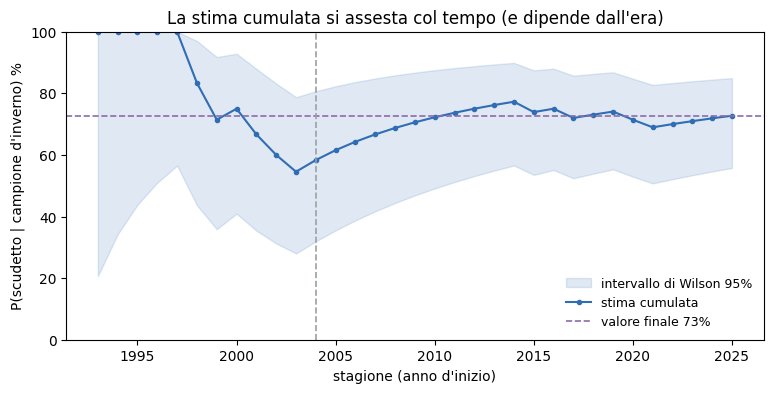

In [9]:
ordine = res.copy()
yy = ordine["season"].str[:2].astype(int)
ordine["anno"] = yy.where(yy >= 90, yy + 100) + 1900
ordine = ordine.sort_values("anno").reset_index(drop=True)
ordine["k"] = ordine["same"].cumsum()
ordine["n"] = range(1, len(ordine) + 1)
ordine["p"] = ordine["k"] / ordine["n"]
lo, hi = proportion_confint(ordine["k"], ordine["n"], method="wilson")

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(ordine["anno"], lo * 100, hi * 100, alpha=0.15, color="#2F6DB5",
                label="intervallo di Wilson 95%")
ax.plot(ordine["anno"], ordine["p"] * 100, color="#2F6DB5", marker="o", ms=3,
        label="stima cumulata")
ax.axhline(res["same"].mean() * 100, color="#8E6BA8", ls="--", lw=1.2,
           label=f"valore finale {res['same'].mean():.0%}")
ax.axvline(2004, color="#9aa0a6", ls="--", lw=1.2)
ax.set_xlabel("stagione (anno d'inizio)")
ax.set_ylabel("P(scudetto | campione d'inverno) %")
ax.set_ylim(0, 100)
ax.set_title("La stima cumulata si assesta col tempo (e dipende dall'era)")
ax.legend(loc="lower right", frameon=False, fontsize=9)
plt.show()

## La forma della classifica al giro di boa

Finora abbiamo guardato *chi* era primo. Ma perché prima del 2004 era meno scontato
vincere da campione d'inverno? L'ipotesi è che sia cambiata la **forma** della
classifica a metà stagione: prima il gruppo di testa era più compatto e più vicino
alla prima; dopo, la prima tende a isolarsi, e dietro la compattezza c'è ancora, ma
più lontana dalla vetta.

Per verificarlo non basta il primo posto: serve la *struttura* della classifica al
giro di boa. Per ogni stagione, all'inverno, calcolo:

- `gap_2` = punti 1ª − 2ª — quanto la prima è già staccata dall'inseguitrice;
- `gap_4` = punti 1ª − 4ª — distanza dal gruppo alta classifica;
- `pack_2_5` = punti 2ª − 5ª — compattezza degli inseguitori (largo = gruppo sfilacciato);
- `entro_5` / `entro_10` = quante squadre stanno entro 5 / 10 punti dalla prima, lei inclusa
  (dimensione del gruppo di testa).

Tutto misurato sulla classifica all'andata, poi confrontato fra l'era a 18 squadre
(≤2003/04) e quella a 20 (2004/05+).

In [ ]:
# Forma della classifica all'inverno, per stagione. La classifica e' gia' ordinata
# (Pts, GD, GF), quindi pts[0] e' la 1a, pts[1] la 2a, ecc.
righe_forma = []
for stagione, df in campionati.items():
    inverno, finale = istantanee_stagione(df)
    pts = inverno["Pts"].to_numpy()
    p1 = pts[0]
    righe_forma.append({
        "season": stagione,
        "n_squadre": inverno.shape[0],
        "gap_2": int(p1 - pts[1]),
        "gap_4": int(p1 - pts[3]),
        "pack_2_5": int(pts[1] - pts[4]),
        "entro_5": int((pts >= p1 - 5).sum()),
        "entro_10": int((pts >= p1 - 10).sum()),
        "vinto": bool(inverno.index[0] == finale.index[0]),
    })
forma = pd.DataFrame(righe_forma)
forma["era"] = forma["n_squadre"].map({18: "18 squadre", 20: "20 squadre"})

tab_forma = forma.groupby("era").agg(
    stagioni=("season", "size"),
    conversione=("vinto", "mean"),
    gap_2_med=("gap_2", "median"),
    gap_4_med=("gap_4", "median"),
    pack_2_5_med=("pack_2_5", "median"),
    entro_5_med=("entro_5", "median"),
    entro_10_med=("entro_10", "median"),
)
tab_forma["conversione"] = (tab_forma["conversione"] * 100).round(0).astype(int).astype(str) + "%"
print("Forma della classifica al giro di boa, mediane per era:")
print(tab_forma.to_string())

In [ ]:
import matplotlib.pyplot as plt

col = {"18 squadre": "#C0504D", "20 squadre": "#2F6DB5"}
e18 = forma[forma["era"] == "18 squadre"]
e20 = forma[forma["era"] == "20 squadre"]

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# 1) istogramma del distacco 1a-2a per era
bins_gap = range(0, int(forma["gap_2"].max()) + 2)
ax[0, 0].hist([e18["gap_2"], e20["gap_2"]], bins=bins_gap,
              color=[col["18 squadre"], col["20 squadre"]], label=["18 squadre", "20 squadre"])
ax[0, 0].set_title("Distacco 1ª-2ª (gap_2) per era")
ax[0, 0].set_xlabel("punti"); ax[0, 0].set_ylabel("stagioni"); ax[0, 0].legend()

# 2) boxplot del distacco 1a-2a per era
ax[0, 1].boxplot([e18["gap_2"], e20["gap_2"]], tick_labels=["18 squadre", "20 squadre"])
ax[0, 1].set_title("Distacco 1ª-2ª (gap_2): boxplot per era")
ax[0, 1].set_ylabel("punti")

# 3) istogramma della compattezza inseguitori 2a-5a per era
bins_pack = range(0, int(forma["pack_2_5"].max()) + 2)
ax[1, 0].hist([e18["pack_2_5"], e20["pack_2_5"]], bins=bins_pack,
              color=[col["18 squadre"], col["20 squadre"]], label=["18 squadre", "20 squadre"])
ax[1, 0].set_title("Compattezza inseguitori 2ª-5ª (pack_2_5) per era")
ax[1, 0].set_xlabel("punti"); ax[1, 0].set_ylabel("stagioni"); ax[1, 0].legend()

# 4) scatter: separazione (x) vs compattezza dietro (y); colore = era, simbolo = esito
for era_lbl, g in forma.groupby("era"):
    for vinto, marker in [(True, "o"), (False, "X")]:
        sub = g[g["vinto"] == vinto]
        ax[1, 1].scatter(sub["gap_2"], sub["pack_2_5"], c=col[era_lbl], marker=marker,
                         s=80, edgecolor="white", linewidth=0.6,
                         label=f"{era_lbl} - {'CI vince' if vinto else 'CI non vince'}")
ax[1, 1].set_xlabel("gap_2  (distacco 1ª-2ª)")
ax[1, 1].set_ylabel("pack_2_5  (compattezza 2ª-5ª)")
ax[1, 1].set_title("Forma della classifica: separazione vs compattezza dietro")
ax[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Come leggere lo scatter.** Le due dimensioni raccontano situazioni diverse:

| gap_2 | pack_2_5 | situazione |
|---|---|---|
| basso | basso | campionato aperto: prima vicina e inseguitrici compatte |
| alto | basso | prima isolata, gruppo dietro compatto ma lontano |
| basso | alto | prima raggiungibile, ma inseguitrici irregolari |
| alto | alto | classifica molto stirata |

**Cosa dicono i numeri.** La sorpresa è che il distacco sulla *seconda* (`gap_2`) è quasi
uguale nelle due ere (mediana 3 contro 3,5): non è da lì che passa la differenza. A cambiare
è l'isolamento dal *gruppo di testa*: `gap_4` raddoppia (6 → 11,5 punti) e le squadre entro 10
punti dalla vetta si dimezzano (6 → 3). Prima la prima aveva sotto un drappello folto e
ravvicinato; nella Serie A a 20 squadre si stacca dall'alta classifica anche quando la seconda
le resta attaccata.

Questo sposta la conclusione da «il campione d'inverno vince spesso» a **«il campione d'inverno
vince spesso quando è già strutturalmente separato dal grosso del gruppo»** — separazione che si
legge meglio in `gap_4` e nel numero di squadre in corsa che nel solo distacco sulla seconda.

**Il distacco sulla seconda: differenza vera o rumore?** Le mediane suggeriscono che `gap_2` non cambia tra le ere (3 vs 3,5), mentre `gap_4`, `pack_2_5` ed `entro_10` sì. Ma con poche stagioni una differenza di mediana può essere solo rumore campionario: serve un test. Uso **Mann-Whitney U**, che confronta due gruppi senza assumere distribuzioni normali ed è adatto a campioni piccoli. Ipotesi nulla: le due ere hanno la stessa distribuzione della variabile.

In [ ]:
# Conferma statistica: le differenze tra le ere sono reali o rumore campionario?
# Mann-Whitney U, non parametrico (niente assunzione di normalita', adatto a n piccoli).
from scipy.stats import mannwhitneyu


def confronto_ere(col):
    x, y = e18[col], e20[col]
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    return {
        "variabile": col,
        "mediana_18": x.median(),
        "mediana_20": y.median(),
        "U": u,
        "p_value": round(p, 4),
    }


test_forma = pd.DataFrame(
    [confronto_ere(c) for c in ["gap_2", "gap_4", "pack_2_5", "entro_10"]]
)
print(f"Mann-Whitney U  -  era 18 squadre ({len(e18)} stagioni) vs era 20 ({len(e20)} stagioni):")
print(test_forma.to_string(index=False))

**Esito.** Il distacco sulla *seconda* (`gap_2`) è l'unico a non mostrare una differenza significativa tra le ere (p ≈ 0,09): coerente con la lettura per cui non è lì che le due ere si distinguono. Tutte le misure di *isolamento dal gruppo* cambiano invece in modo significativo: `gap_4` (p ≈ 0,002), la compattezza degli inseguitori `pack_2_5` (p ≈ 0,03) e le squadre entro 10 punti `entro_10` (p ≈ 0,003). Il test mette quindi un numero sotto la conclusione descrittiva: a cambiare non è il margine sulla seconda, ma la separazione dal grosso del gruppo di testa.

**Cautela sulla potenza.** Con 11 stagioni in un'era e 22 nell'altra il test ha poca potenza: il `gap_2` non significativo va letto come «differenza troppo piccola per distinguerla dal rumore», non come prova che le due ere siano identiche su quel fronte.

## Difesa o attacco?

Un'altra caratteristica del campione, oltre ai punti: arriva piu' spesso con la
miglior difesa o col miglior attacco? Nei numeri la difesa pesa di piu' — il
vecchio adagio "la difesa vince i campionati" regge. (Questo riguarda chi *diventa*
campione, non chi *converte* un primato d'inverno: la' conta solo il distacco.)

In [10]:
righe_ad = []
for stagione, df in campionati.items():
    inverno, finale = istantanee_stagione(df)
    fc = finale.index[0]
    righe_ad.append({
        "mig_attacco": finale.loc[fc, "GF"] == finale["GF"].max(),
        "mig_difesa": finale.loc[fc, "GA"] == finale["GA"].min(),
    })
ad = pd.DataFrame(righe_ad)
print(f"Campione d'Italia con miglior attacco: {ad['mig_attacco'].sum()}/{len(ad)} = {ad['mig_attacco'].mean():.0%}")
print(f"Campione d'Italia con miglior difesa : {ad['mig_difesa'].sum()}/{len(ad)} = {ad['mig_difesa'].mean():.0%}")
print(f"Con entrambi i primati: {(ad['mig_attacco'] & ad['mig_difesa']).sum()}/{len(ad)}")

Campione d'Italia con miglior attacco: 13/33 = 39%
Campione d'Italia con miglior difesa : 24/33 = 73%
Con entrambi i primati: 9/33


## Domanda 2 - e l'Inter?

La probabilità storica è una media. Qui proviamo a stimarla a partire da quanto era forte il campione d'inverno: differenza reti e distacco sul secondo a metà stagione. Poi applichiamo il modello al caso dell'Inter.

In [11]:
setDati = costruisci_dataset(campionati)
print(f"Dataset creato con {len(setDati)} record storici.")
print(setDati)

Dataset creato con 33 record storici.
          Team Season  GapOnSecond  GD  WonScudetto
0         Roma   0001            6  20            1
1         Roma   0102            4  17            0
2        Milan   0203            3  23            0
3         Roma   0304            0  29            0
4     Juventus   0405            2  23            1
5     Juventus   0506           10  31            1
6        Inter   0607            9  25            1
7        Inter   0708            5  30            1
8        Inter   0809            3  18            1
9        Inter   0910            6  24            1
10       Milan   1011            4  17            1
11    Juventus   1112            1  20            1
12    Juventus   1213            5  27            1
13    Juventus   1314            8  34            1
14    Juventus   1415            5  33            1
15      Napoli   1516            4  25            0
16    Juventus   1617            1  24            1
17      Napoli   1718     

# ML: Classificazione

In [12]:
features = ["GD", "GapOnSecond"]
X = setDati[features]
y = setDati["WonScudetto"]

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.80,random_state=42)

In [14]:
model = LogisticRegression()

model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:,1]
preds = model.predict(X_test)

from sklearn.metrics import accuracy_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))

Accuracy: 0.5714285714285714
ROC AUC: 0.5833333333333334


In [15]:
X = setDati.drop(columns=["Team", "Season", "WonScudetto"])
y = setDati["WonScudetto"]

In [16]:
loo = LeaveOneOut()

model = LogisticRegression()

y_true = []
y_pred = []
y_prob = []

In [17]:
for train_index, test_index in loo.split(X):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)

    pred = model.predict(X_test)[0]
    prob = model.predict_proba(X_test)[0][1]

    y_pred.append(pred)
    y_prob.append(prob)
    y_true.append(y_test.values[0])

In [18]:
print("Accuracy:", accuracy_score(y_true, y_pred))
print("ROC AUC:", roc_auc_score(y_true, y_prob))

Accuracy: 0.6666666666666666
ROC AUC: 0.5787037037037037


In [19]:
print("Probabilità media scudetto campione d'inverno:", np.mean(y_prob))

Probabilità media scudetto campione d'inverno: 0.728102692542545


### L'Inter 2025/26: una prova out-of-sample

La 25/26 ormai è osservata: l'Inter, campione d'inverno, ha vinto lo scudetto.
Non c'è niente da "prevedere". Facciamo però una prova onesta: nascondiamo la
25/26, addestriamo il modello sulle altre stagioni, e vediamo che probabilità
avrebbe dato all'Inter da confrontare con la realtà.

In [20]:
# Prova out-of-sample: modello addestrato su tutte le stagioni TRANNE la 25/26,
# poi predice l'Inter 25/26 con le sue statistiche vere all'inverno.
inter = setDati[setDati["Season"] == "2526"]
altre = setDati[setDati["Season"] != "2526"]

modello_oos = LogisticRegression().fit(altre[features], altre["WonScudetto"])
prob = modello_oos.predict_proba(inter[features])[0][1]

print(f"Inter 25/26 all'inverno: GapOnSecond={int(inter.iloc[0]['GapOnSecond'])}, GD={int(inter.iloc[0]['GD'])}")
print(f"Probabilita' out-of-sample di vincere lo scudetto: {prob:.1%}")
print(f"Esito reale: {'vinto' if int(inter.iloc[0]['WonScudetto']) else 'non vinto'}")

Inter 25/26 all'inverno: GapOnSecond=3, GD=25
Probabilita' out-of-sample di vincere lo scudetto: 69.8%
Esito reale: vinto


## Bontà del modello

Con così pochi dati la valutazione onesta è quella out-of-fold: uso le predizioni della cross-validation Leave-One-Out (ogni stagione predetta da un modello che non l'ha vista). ROC e matrice di confusione su quelle.

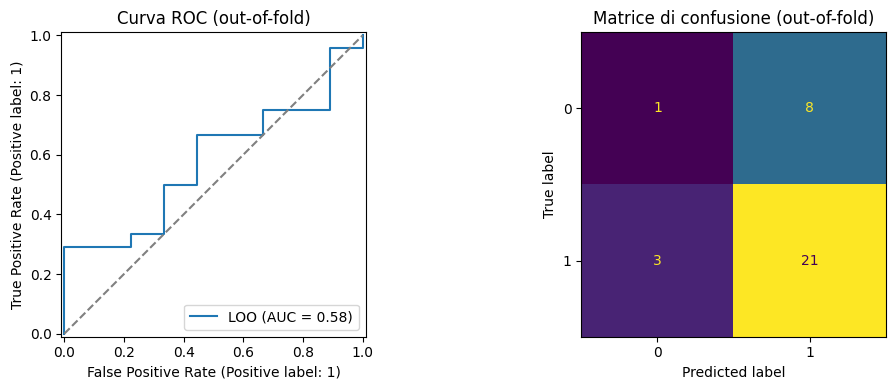

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

RocCurveDisplay.from_predictions(y_true, y_prob, ax=ax[0], name="LOO")
ax[0].plot([0, 1], [0, 1], "--", color="grey")
ax[0].set_title("Curva ROC (out-of-fold)")

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax[1], colorbar=False)
ax[1].set_title("Matrice di confusione (out-of-fold)")

plt.tight_layout()
plt.show()

## Logistica in ottica statistica

A n=32 la lettura utile e' descrittiva, non predittiva. Stessa regressione
logistica, ma guardata sui **parametri**: coefficienti, p-value, odds ratio
(`exp` del coefficiente), pseudo-R^2. Con cosi' pochi dati gli intervalli sono
ampi: si leggono segno e ordine di grandezza, non certezze.

In [22]:
import numpy as np
import statsmodels.api as sm

X_sm = sm.add_constant(X)
logit = sm.Logit(y, X_sm).fit()
print(logit.summary())
print("\nOdds ratio (exp dei coefficienti):")
print(np.exp(logit.params).round(3))

Optimization terminated successfully.
         Current function value: 0.503640
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            WonScudetto   No. Observations:                   33
Model:                          Logit   Df Residuals:                       30
Method:                           MLE   Df Model:                            2
Date:                Tue, 16 Jun 2026   Pseudo R-squ.:                  0.1405
Time:                        16:53:31   Log-Likelihood:                -16.620
converged:                       True   LL-Null:                       -19.336
Covariance Type:            nonrobust   LLR p-value:                   0.06612
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.1334      1.463      0.091      0.927      -2.733       3.000
GapOnSecond     0.4437    

## Esplorazione di altre feature

Oltre a `GapOnSecond` (= `gap_2`) e `GD`, provo altri regressori calcolati per il
campione d'inverno a fine andata. Due famiglie.

**Forza del primo:** **forza assoluta** (`PtsPerGame` = punti/partita), **attacco** e
**difesa** separati (`GF_pg`, `GA_pg` = gol fatti/subiti per partita), e la
**contendibilità verso la vetta** (`rivali5` = quante inseguitrici sono entro 5 punti
dalla prima).

**Forma della classifica** (gli stessi indicatori della sezione sul giro di boa):
`gap_4` = distacco 1ª−4ª (isolamento dal gruppo di testa), `pack_2_5` = 2ª−5ª
(compattezza interna degli inseguitori), `entro_5` / `entro_10` = quante squadre entro
5 / 10 punti dalla prima.

Si testano in chiave statistica (statsmodels), guardando pseudo-R² e p-value. Il dato
che emerge: il segnale migliore non è il distacco sulla seconda ma **`gap_4`**, cioè
quanto la prima è già staccata dal grosso del gruppo di testa (pseudo-R² 0,15, p≈0,04,
contro 0,14 e p≈0,07 di `gap_2`). `pack_2_5` ed `entro_10` da soli non dicono nulla. Le
combinazioni alzano lo pseudo-R², ma i regressori di forma sono molto correlati tra loro
(`gap_4` con `gap_2` e con `pack_2_5`), quindi a n=33 i singoli p-value si gonfiano e non
si può separare il contributo di ciascuno: si legge il blocco, non la singola variabile.

In [ ]:
import statsmodels.api as sm

righe = []
for stagione, df in campionati.items():
    inverno, _ = istantanee_stagione(df)
    primo = inverno.iloc[0]
    pts = inverno["Pts"].to_numpy()
    altri = inverno["Pts"].iloc[1:]
    won = setDati.loc[setDati["Season"] == stagione, "WonScudetto"].iloc[0]
    righe.append({
        # forza/attacco/difesa del primo
        "GapOnSecond": int(pts[0] - pts[1]),                # = gap_2, distacco sulla 2a
        "PtsPerGame": primo["Pts"] / primo["GP"],           # forza assoluta
        "GF_pg": primo["GF"] / primo["GP"],                 # attacco
        "GA_pg": primo["GA"] / primo["GP"],                 # difesa
        "rivali5": int((altri >= primo["Pts"] - 5).sum()),  # contendibilita' verso la vetta
        # forma della classifica al giro di boa
        "gap_4": int(pts[0] - pts[3]),                      # isolamento dal gruppo top-4
        "pack_2_5": int(pts[1] - pts[4]),                   # compattezza interna inseguitori
        "entro_5": int((pts >= pts[0] - 5).sum()),          # gruppo di testa stretto (1a inclusa)
        "entro_10": int((pts >= pts[0] - 10).sum()),        # gruppo di testa largo (1a inclusa)
        "WonScudetto": won,
    })
feat = pd.DataFrame(righe)


def prova(cols):
    m = sm.Logit(feat["WonScudetto"], sm.add_constant(feat[cols])).fit(disp=0)
    pv = {k: round(v, 3) for k, v in m.pvalues.items() if k != "const"}
    print(f"{cols}: pseudo-R2={m.prsquared:.3f}  p={pv}")


print("Regressori di forma della classifica (singoli):")
for cols in [["GapOnSecond"], ["gap_4"], ["pack_2_5"], ["entro_5"], ["entro_10"]]:
    prova(cols)

print("\nForza/attacco/difesa del primo (singoli):")
for cols in [["PtsPerGame"], ["GF_pg", "GA_pg"], ["rivali5"]]:
    prova(cols)

print("\nCombinazioni:")
for cols in [["GapOnSecond", "gap_4"], ["gap_4", "pack_2_5"], ["GapOnSecond", "rivali5"]]:
    prova(cols)

print("\nCorrelazioni tra i regressori di forma:")
print(feat[["GapOnSecond", "gap_4", "pack_2_5", "entro_5", "entro_10"]].corr().round(2).to_string())

## In sintesi

- Storicamente il campione d'inverno vince lo scudetto circa il 73% delle volte (24 su 33).
- Conta soprattutto il distacco sul secondo a metà stagione, non la differenza reti.
- L'Inter 2025/26, campione d'inverno, ha vinto; un modello out-of-sample le dava ~70% (dalla parte giusta, ma quasi pari al tasso storico).

33 stagioni sono comunque poche: è una tendenza, non una legge. Da qui le altre domande - altre tecniche statistiche e più dati (vedi README).